# Layer 5: the recipe on a generative problem, flow matching

Layers [00](00_single_cell.ipynb)-[03](03_scaling_analysis.ipynb) extracted scaling laws for a
regression task with a synthetic teacher. Here the same recipe runs on a **generative** problem:
learn a velocity field that transports a 2D Gaussian into the two-moons distribution by
**conditional flow matching** (Lipman et al. 2023; the linear path is the rectified-flow choice).
The role of the teacher is now played by the data-generating process itself.

Sample $x_0\sim\mathcal N(0,I_2)$, $x_1\sim$ two moons, $t\sim U[0,1]$, and set
$x_t=(1-t)\,x_0+t\,x_1$. The network $v_\theta(x_t,t):\mathbb R^2\times[0,1]\to\mathbb R^2$
regresses the conditional velocity:

$$\mathcal L(\theta)=\mathbb E\,\big\|v_\theta(x_t,t)-(x_1-x_0)\big\|^2
= \underbrace{\mathbb E\big[\mathrm{tr}\,\mathrm{Var}(x_1-x_0\mid x_t,t)\big]}_{E,\ \text{irreducible}}
\;+\;\text{excess}(\theta).$$

This is plain MSE regression, so **the whole pipeline applies unchanged**. What changes:

| | regression (00-03) | flow matching (this notebook) |
|---|---|---|
| ground truth | frozen teacher network | the data-generating process |
| target | $y=f_\text{teacher}(x)+\sigma\varepsilon$ | $v=x_1-x_0$ |
| input / output | $x\in\mathbb R^{32}$ / $\mathbb R$ | $(x_t,t)\in\mathbb R^{3}$ / $\mathbb R^2$ |
| irreducible floor | **known**, $E=\sigma^2$ | **unknown**: the conditional variance of $v$ |
| success metric | loss only | loss, and the generated samples |

The floor exists because many $(x_0,x_1)$ pairs pass through the same $(x_t,t)$; the optimal
field predicts their conditional mean. Unlike $\sigma^2$ it has no closed form, so it must be
estimated or fitted, which is where Approach 3 earns its keep.

> **Training happens in scripts**, exactly as before:
> ```
> python scripts/run_flow_hp_study.py   # calibrate the LR law (results/flow_hp_study_cosine.json)
> python scripts/run_flow_sweep.py      # train the (N,D) grid -> results/flow_sweep_cosine.csv
> ```

LR law: eta*(w,T) = 0.02975 (w/64)^-0.58 (T/2048)^-0.415


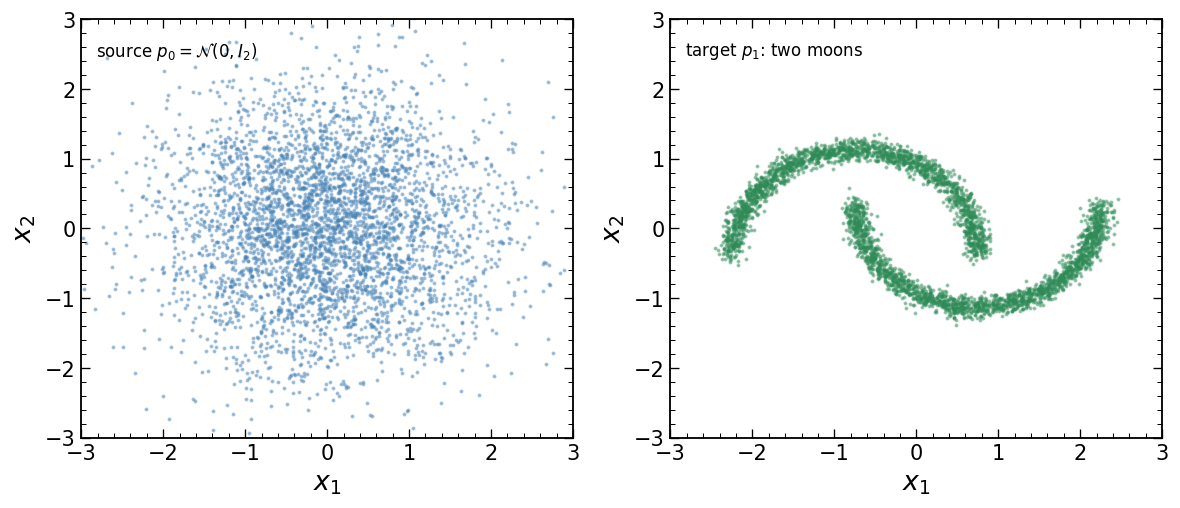

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from scaling_laws.flow import FlowMatchingProblem, two_moons
from scaling_laws.live import train_cell_live
from scaling_laws.sweep import aggregate, transfer_lr
from scaling_laws import approaches as ap, plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
prob = FlowMatchingProblem()
law = json.load(open(RESULTS / "flow_hp_study_cosine.json"))
lr_of = transfer_lr(eta_ref=law["eta_ref"], w_ref=law["w_ref"], T_ref=law["T_ref"],
                    c_w=law["c_w"], c_T=law["c_T"], lr_max=0.1)
print(f"LR law: eta*(w,T) = {law['eta_ref']} (w/{law['w_ref']})^{law['c_w']} (T/{law['T_ref']})^{law['c_T']}")

g = torch.Generator().manual_seed(0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
axes[0].scatter(*torch.randn(4000, 2, generator=g).T, s=2, alpha=.4, color="steelblue")
axes[1].scatter(*two_moons(4000, generator=g).T, s=2, alpha=.4, color="seagreen")
for a, l in zip(axes, [r"source $p_0=\mathcal{N}(0,I_2)$", r"target $p_1$: two moons"]):
    a.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="$x_1$", ylabel="$x_2$")
    a.text(.03, .95, l, transform=a.transAxes, va="top", fontsize=10)
fig.tight_layout(); plt.show()

## Watch one velocity field train

Exactly the layer-0 live loop, on the new problem (the model just has 3 inputs and 2 outputs).
One difference is visible immediately: **no floor line**, because for this problem we do not
know $E$ a priori. The training loss will flatten anyway; where it flattens *is* (an estimate
of) the floor.

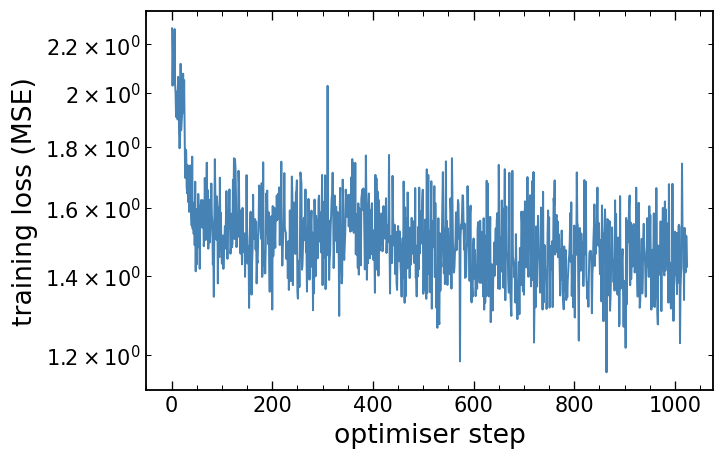

w=64, D=262,144:   0%|          | 0/1024 [00:00<?, ?step/s]

w=64, D=262,144:   2%|▏         | 25/1024 [00:00<00:04, 221.90step/s]

w=64, D=262,144:   7%|▋         | 69/1024 [00:00<00:02, 342.93step/s]

w=64, D=262,144:  10%|█         | 104/1024 [00:00<00:03, 255.68step/s]

w=64, D=262,144:  14%|█▍        | 146/1024 [00:00<00:02, 307.89step/s]

...

w=64, D=262,144:  90%|████████▉ | 917/1024 [00:03<00:00, 248.99step/s]

w=64, D=262,144:  93%|█████████▎| 950/1024 [00:03<00:00, 231.16step/s]

w=64, D=262,144:  96%|█████████▋| 987/1024 [00:04<00:00, 263.05step/s]

w=64, D=262,144: 100%|█████████▉| 1023/1024 [00:04<00:00, 247.23step/s]

w=64, D=2^18: validation CFM loss = 1.4565


In [2]:
D = 2**18
val, steps, losses, model = train_cell_live(prob, 64, D, lr_of(64, prob.n_steps(D, 256)),
                                            return_model=True)
print(f"w=64, D=2^18: validation CFM loss = {val:.4f}")

The loss is one number; for a generative model we can also *look at the result*. Integrate
$\dot x = v_\theta(x, t)$ from $t{=}0$ to $1$ (midpoint rule, 100 steps) starting from fresh
Gaussian samples:

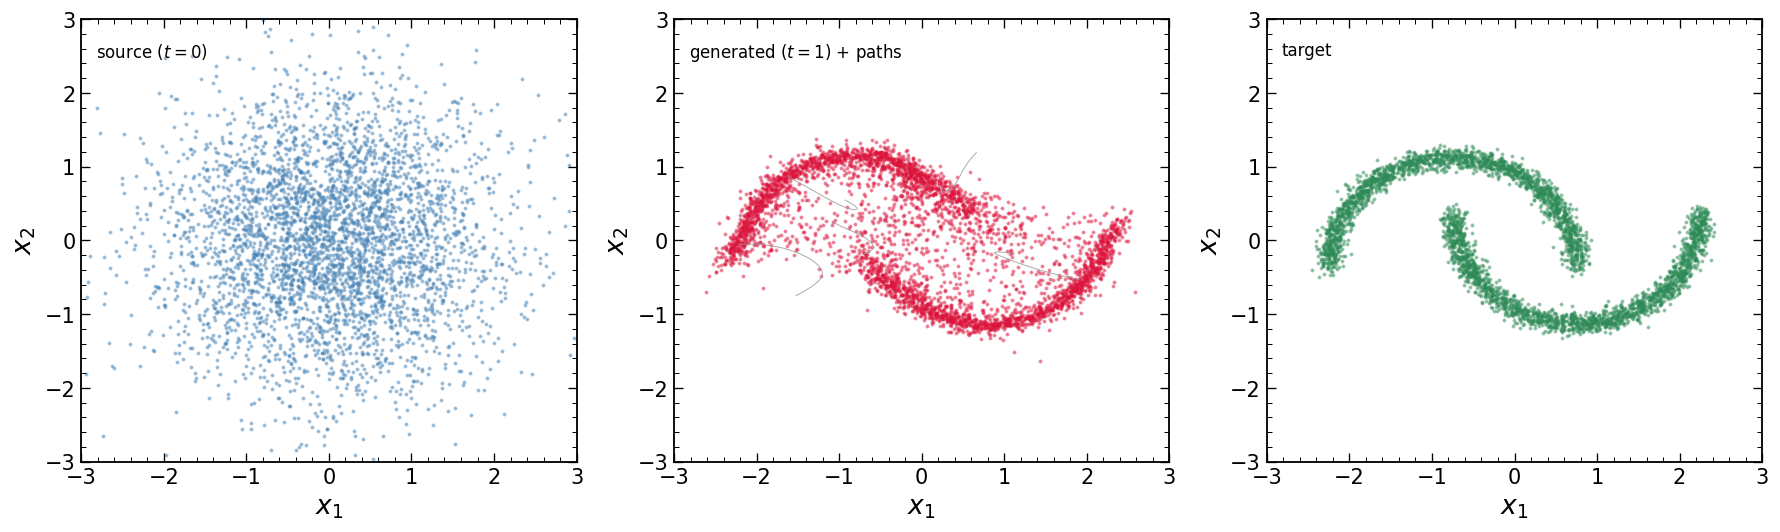

In [3]:
xg, traj = prob.sample(model, n=4000, steps=100, seed=1, return_traj=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].scatter(*traj[0].T, s=2, alpha=.4, color="steelblue")
axes[1].scatter(*xg.T, s=2, alpha=.4, color="crimson")
axes[2].scatter(*two_moons(4000, generator=torch.Generator().manual_seed(7)).T,
                s=2, alpha=.4, color="seagreen")
for k in range(0, 60, 12):                                   # a few transport paths
    axes[1].plot(traj[:, k, 0], traj[:, k, 1], color="0.6", lw=.6, alpha=.8)
for a, l in zip(axes, ["source ($t=0$)", "generated ($t=1$) + paths", "target"]):
    a.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="$x_1$", ylabel="$x_2$")
    a.text(.03, .95, l, transform=a.transAxes, va="top", fontsize=10)
fig.tight_layout()
pl.save_figure(fig, "flow_one_field", outdir=FIGDIR); plt.show()

## The generation ladder: loss down, moons sharpen

Train a ladder of cells of growing model size and data budget (each takes seconds) and look at
their samples. The validation loss falls by only a few percent, because it is dominated by the
constant floor $E$, while the sample quality changes completely. This is the generative
counterpart of the excess loss: small differences above the floor are exactly what separates a
blob from two crisp moons.

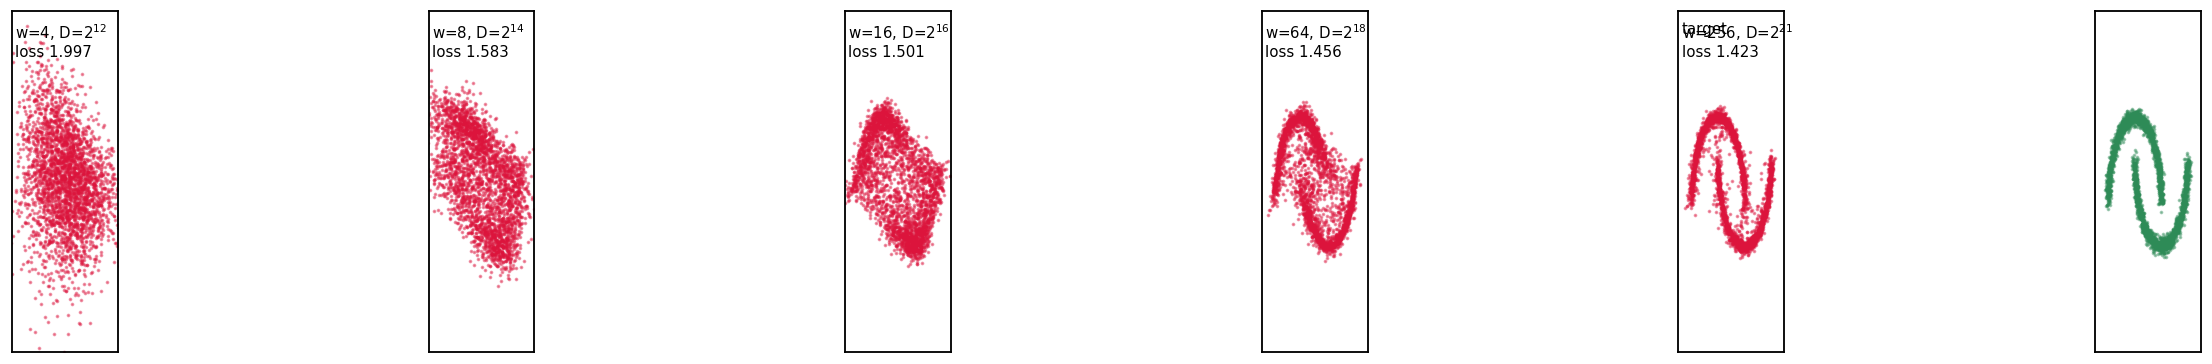

In [4]:
ladder = [(4, 2**12), (8, 2**14), (16, 2**16), (64, 2**18), (256, 2**21)]
fig, axes = plt.subplots(1, len(ladder) + 1, figsize=(3.1 * (len(ladder) + 1), 3.2))
for a, (w, D) in zip(axes, ladder):
    lv, _, _, m = train_cell_live(prob, w, D, lr_of(w, prob.n_steps(D, 256)),
                                  plot=False, progress=False, return_model=True)
    a.scatter(*prob.sample(m, 3000, seed=2).T, s=1.5, alpha=.4, color="crimson")
    a.text(.03, .97, f"w={w}, D=$2^{{{int(np.log2(D))}}}$\nloss {lv:.3f}",
           transform=a.transAxes, va="top", fontsize=9)
axes[-1].scatter(*two_moons(3000, generator=torch.Generator().manual_seed(3)).T,
                 s=1.5, alpha=.4, color="seagreen")
axes[-1].text(.03, .97, "target", transform=a.transAxes, va="top", fontsize=9)
for a in axes:
    a.set(xlim=(-3, 3), ylim=(-3, 3), xticks=[], yticks=[])
fig.tight_layout()
pl.save_figure(fig, "flow_generation_ladder", outdir=FIGDIR); plt.show()

## The full grid, three ways

[`run_flow_sweep.py`](../scripts/run_flow_sweep.py) trained the $(N,D)$ grid, every cell at its
own $\eta^\star(w,T)$ from the flow-calibrated law. The pipeline from
[notebook 03](03_scaling_analysis.ipynb) applies verbatim; only the CSV changes. Note the
compressed loss axis: everything lives a few percent above the floor, as in LLM scaling, where
the entropy of text plays the same role.

grid: 8 model sizes x 12 data budgets, N from 46 to 150,146 params


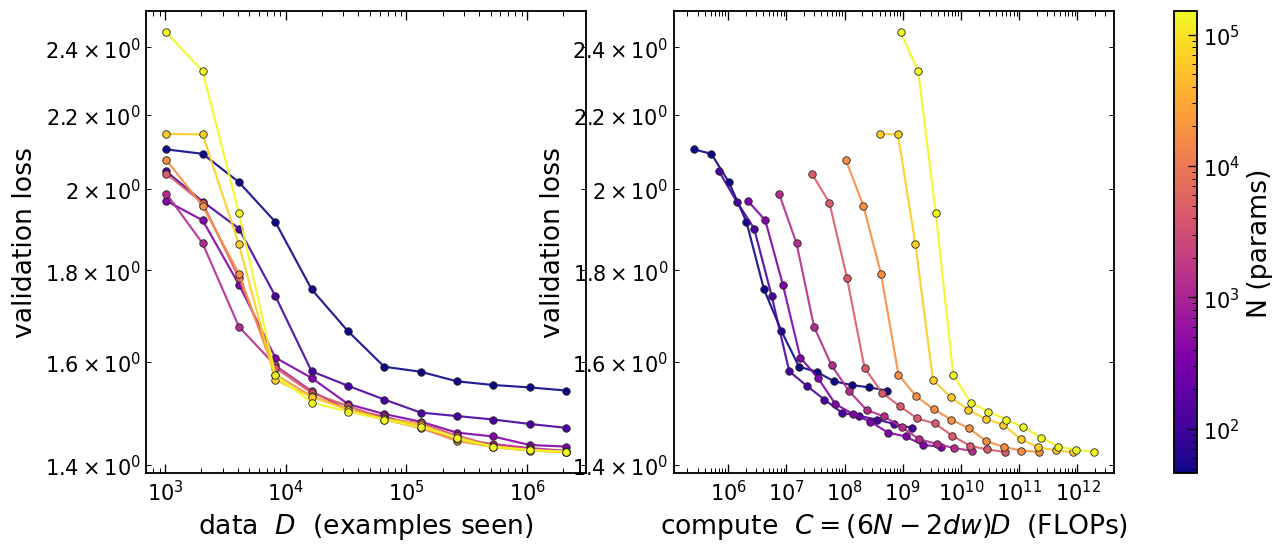

In [5]:
agg = aggregate(pd.read_csv(RESULTS / "flow_sweep_cosine.csv"))
print(f"grid: {agg['N'].nunique()} model sizes x {agg['D'].nunique()} data budgets, "
      f"N from {agg['N'].min()} to {agg['N'].max():,} params")
fig = pl.plot_all_runs(agg)
pl.save_figure(fig, "flow_overview", outdir=FIGDIR); plt.show()

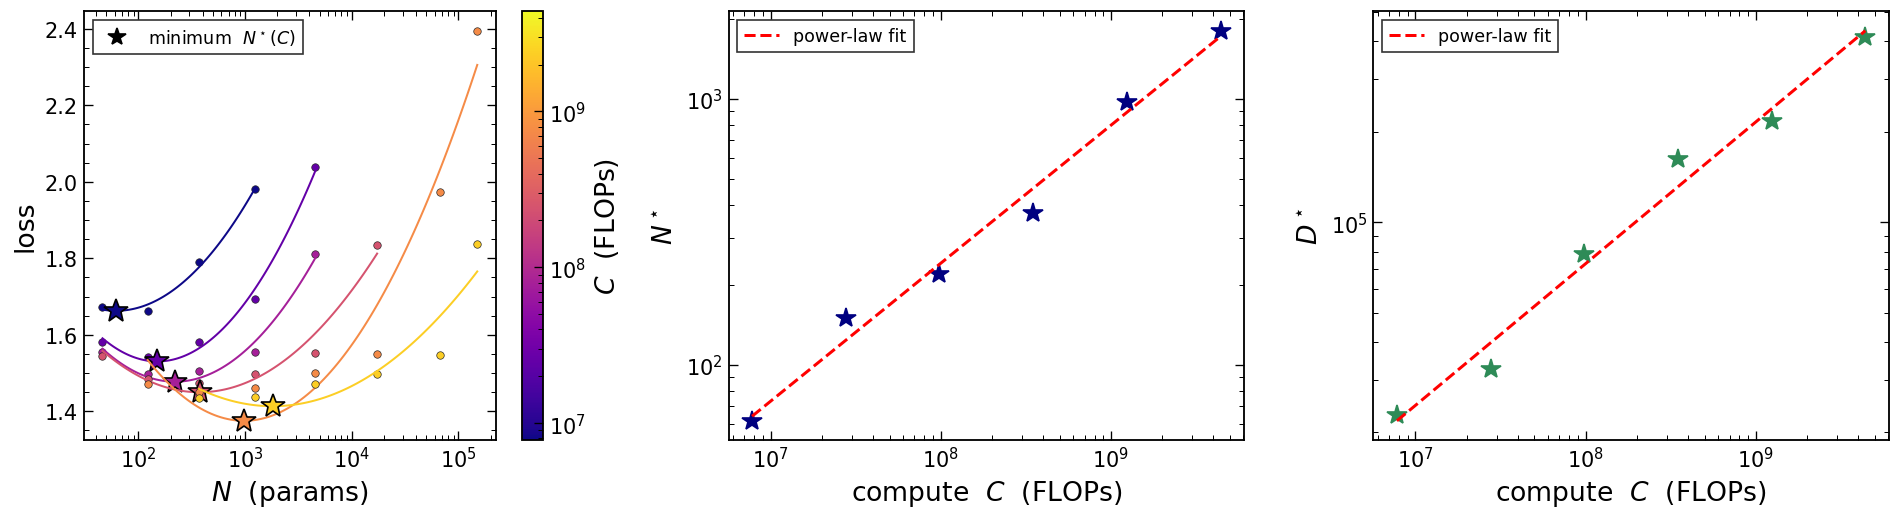

In [6]:
env = ap.training_curve_envelope(agg)
iso = ap.isoflop_profiles(agg, n_targets=8)
par = ap.parametric_fit(agg)
fig = pl.plot_isoflop(iso)
pl.save_figure(fig, "flow_isoflop", outdir=FIGDIR); plt.show()

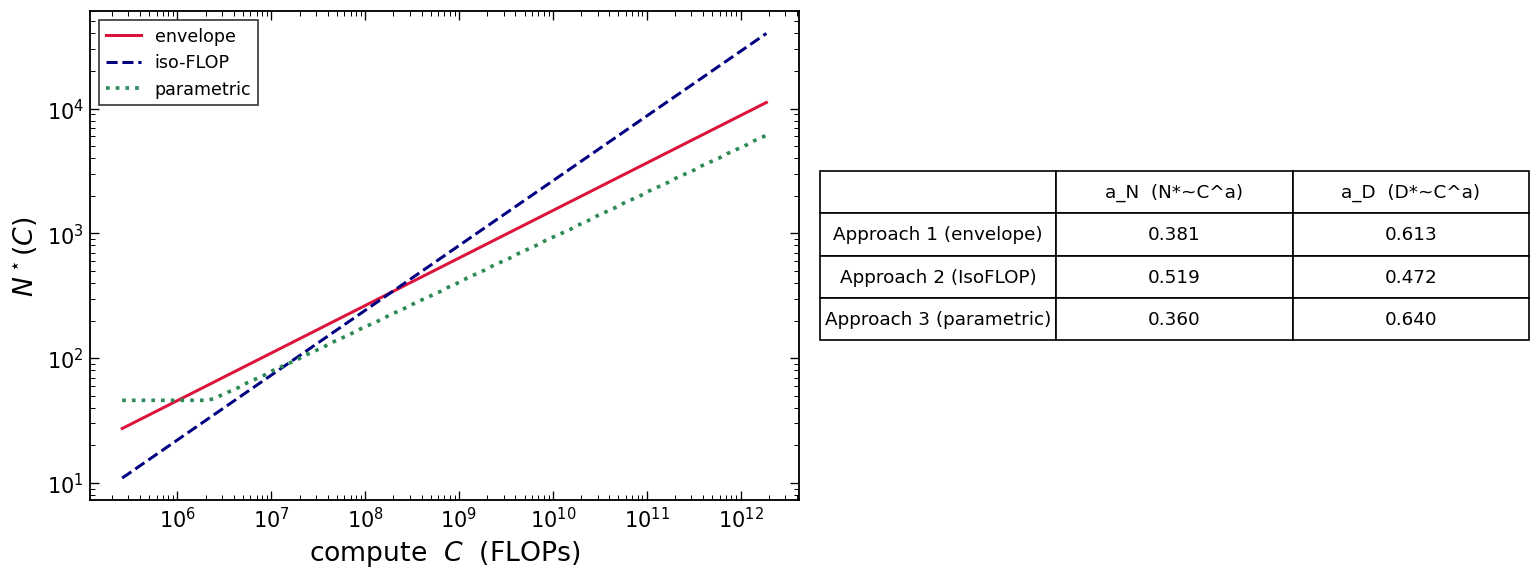

fitted floor (Approach 3):  E = 1.4142
exponents: alpha = 1.021, beta = 0.575


In [7]:
fig = pl.plot_comparison(env, iso, par, (agg["C"].min(), agg["C"].max()))
pl.save_figure(fig, "flow_comparison", outdir=FIGDIR); plt.show()
print(f"fitted floor (Approach 3):  E = {par.E:.4f}")
print(f"exponents: alpha = {par.alpha:.3f}, beta = {par.beta:.3f}")

## Grading the fitted floor

For the teacher we knew $E=\sigma^2$; here we need estimates to grade Approach 3 against.

1. **A reference model**: train one model far larger and longer than the grid and read off its
   converged loss (an upper bound on $E$, tight if the model has effectively converged).
2. **Importance sampling**: for a point $(x_t,t)$, every pair passing through it satisfies
   $x_0=(x_t-t\,x_1)/(1-t)$, so the conditional variance of $v=(x_1-x_t)/(1-t)$ is a weighted
   average over the target distribution with weights $p_0\!\big((x_t-t\,x_1)/(1-t)\big)$. The
   estimator degenerates as $t\to1$ (too few moons carry weight), so we restrict it to
   $t\le0.9$ and compare against the validation loss **on the same $t\le0.9$ subset**.

In [8]:
D_ref = 2**22
val_ref, _, _, ref = train_cell_live(prob, 512, D_ref, lr_of(512, prob.n_steps(D_ref, 256)),
                                     plot=False, progress=True, return_model=True)
E_is, ess = prob.estimate_floor(n_points=4096, t_max=0.9)
mask = prob.x_val[:, 2] <= 0.9
sub = torch.nn.functional.mse_loss(ref(prob.x_val[mask]), prob.v_val[mask]).item()
print(f"reference model (w=512, D=2^22): loss = {val_ref:.4f}   <- empirical floor")
print(f"Approach 3 fitted floor:        E    = {par.E:.4f}")
print(f"IS floor, t<=0.9:               E    = {E_is:.4f}  (mean ESS {ess:.0f})")
print(f"reference model on t<=0.9:             {sub:.4f}  (apples-to-apples check)")

w=512, D=4,194,304:   0%|          | 0/16384 [00:00<?, ?step/s]

w=512, D=4,194,304:   0%|          | 48/16384 [00:00<00:34, 473.49step/s]

w=512, D=4,194,304:   1%|          | 96/16384 [00:00<00:34, 475.85step/s]

w=512, D=4,194,304:   1%|          | 145/16384 [00:00<00:33, 480.51step/s]

w=512, D=4,194,304:   1%|          | 195/16384 [00:00<00:33, 484.44step/s]

...

w=512, D=4,194,304:  99%|█████████▉| 16256/16384 [00:33<00:00, 464.25step/s]

w=512, D=4,194,304: 100%|█████████▉| 16304/16384 [00:34<00:00, 468.83step/s]

w=512, D=4,194,304: 100%|█████████▉| 16354/16384 [00:34<00:00, 477.59step/s]

w=512, D=4,194,304: 100%|█████████▉| 16383/16384 [00:34<00:00, 479.25step/s]

reference model (w=512, D=2^22): loss = 1.4222   <- empirical floor
Approach 3 fitted floor:        E    = 1.4142
IS floor, t<=0.9:               E    = 1.4547  (mean ESS 69523)
reference model on t<=0.9:             1.4753  (apples-to-apples check)


## The anatomy, in excess loss

With the reference floor subtracted, the compressed frontier opens up into the familiar
three-regime picture of [notebook 03](03_scaling_analysis.ipynb): a steep data-driven descent,
a scaling stretch, and saturation once the excess approaches the resolution of the estimate.

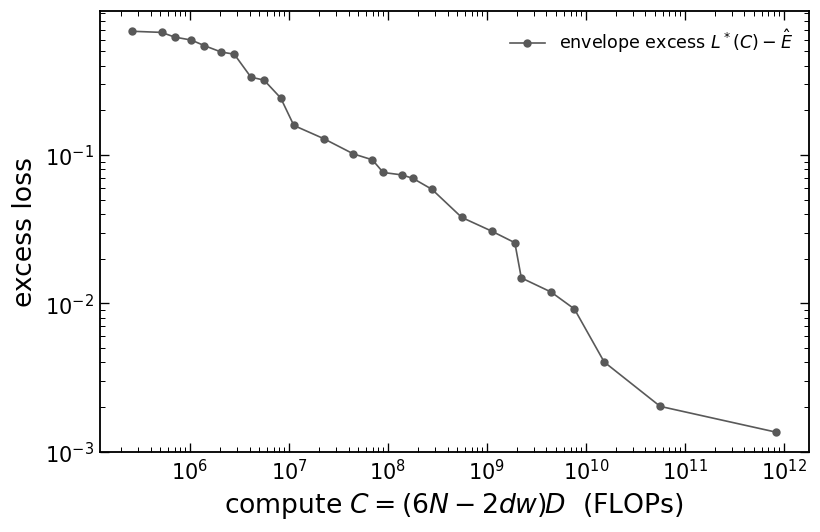

In [9]:
fr = env.frontier.sort_values("C")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(fr["C"], fr["val_loss"] - val_ref, "o-", color="0.35", ms=4, lw=1,
        label=r"envelope excess $L^*(C)-\hat E$")
ax.set(xscale="log", yscale="log", xlabel=r"compute $C=(6N-2dw)D$  (FLOPs)",
       ylabel=r"excess loss")
ax.legend(frameon=False)
fig.tight_layout()
pl.save_figure(fig, "flow_excess", outdir=FIGDIR); plt.show()

## Takeaways

- **The recipe transfers wholesale.** Streaming single-pass cells, per-cell LR from a
  re-calibrated transfer law, the same three extraction approaches: nothing about the pipeline
  is specific to the teacher-student task.
- **The floor is now a measurement.** With no known $\sigma^2$, the irreducible loss must be
  estimated (reference model, importance sampling) or fitted (Approach 3); their agreement is
  the consistency check.
- **Loss differences near the floor carry the quality.** The generation ladder shows a few
  percent of excess loss separating noise from clean moons; on floor-dominated problems, small
  loss gaps matter.
- **Batch size is held fixed** at $b=256$ throughout, as in the rest of the tutorial; in
  principle it should be tuned and scaled jointly with $\eta$.